# Pharmacy OTC Sales Forecasting

## Objective
- Import and explore the dataset (check trends, seasonality, missing values)
- Perform data preprocessing (handle missing values, convert dates, extract features)
- Split into training and testing sets
- Apply multiple forecasting models: Linear Regression, ARIMA, Random Forest, Prophet
- Evaluate performance using MAE, RMSE, and R² score
- Summarize observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

d:\Coding\Data science\DS_Assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Step 1: Load and Explore the Dataset

In [2]:
df = pd.read_csv("pharmacy_otc_sales_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (333, 6)


,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country
0,2022-02-06,Pain Relief Tablets,Divya Mehra,7,67.43,Australia
1,2022-02-05,Antiseptic Cream,Nikhil Batra,18,421.46,Canada
2,2022-02-19,Cough Syrup,Ritika Shah,2,48.25,UK
3,2022-03-28,Pain Relief Tablets,Nikhil Batra,5,59.89,UK
4,2022-01-17,Digestive Enzyme,Ritika Shah,8,147.73,USA


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           333 non-null    str    
 1   Product        333 non-null    str    
 2   Sales Person   333 non-null    str    
 3   Boxes Shipped  333 non-null    int64  
 4   Amount ($)     333 non-null    float64
 5   Country        333 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 15.7 KB


In [4]:
df.describe()

,Boxes Shipped,Amount ($)
count,333.000000,333.000000
mean,10.474474,176.964835
std,5.955415,119.058556
min,1.000000,8.090000
25%,5.000000,75.990000
50%,11.000000,156.920000
75%,16.000000,248.770000
max,20.000000,494.080000


## Step 2: Check for Missing Values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicates:", df.duplicated().sum())

Missing values per column:
Date             0
Product          0
Sales Person     0
Boxes Shipped    0
Amount ($)       0
Country          0
dtype: int64

Total duplicates: 0


## Step 3: Data Preprocessing
- Convert `Date` to datetime
- Extract Year, Month, Day, Weekday

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Day']     = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

df.head()

,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country,Year,Month,Day,Weekday
0,2022-02-06,Pain Relief Tablets,Divya Mehra,7,67.43,Australia,2022,2,6,Sunday
1,2022-02-05,Antiseptic Cream,Nikhil Batra,18,421.46,Canada,2022,2,5,Saturday
2,2022-02-19,Cough Syrup,Ritika Shah,2,48.25,UK,2022,2,19,Saturday
3,2022-03-28,Pain Relief Tablets,Nikhil Batra,5,59.89,UK,2022,3,28,Monday
4,2022-01-17,Digestive Enzyme,Ritika Shah,8,147.73,USA,2022,1,17,Monday


## Step 4: Exploratory Data Analysis (Trends & Seasonality)

In [7]:
daily_sales = df.groupby('Date')['Amount ($)'].sum().reset_index()
daily_sales = daily_sales.sort_values('Date')

# Fill missing dates for continuous time series
daily_sales = daily_sales.set_index('Date').asfreq('D').fillna(0).reset_index()

print("Daily sales shape:", daily_sales.shape)
daily_sales.head()

Daily sales shape: (242, 2)


,Date,Amount ($)
0,2022-01-02,244.41
1,2022-01-03,0.00
2,2022-01-04,0.00
3,2022-01-05,247.43
4,2022-01-06,54.15


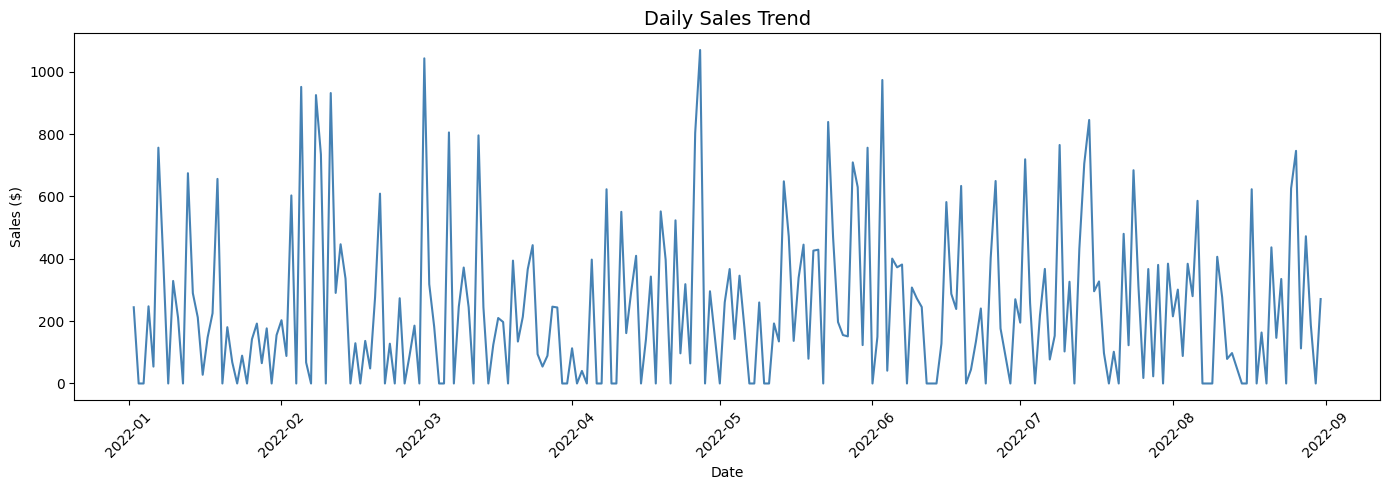

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['Date'], daily_sales['Amount ($)'], color='steelblue')
plt.title("Daily Sales Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

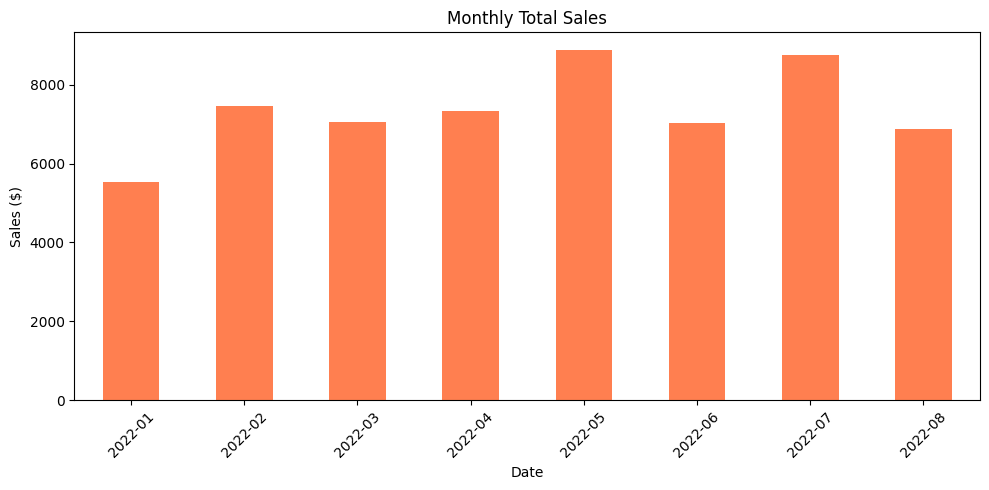

In [9]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount ($)'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar', color='coral')
plt.title("Monthly Total Sales")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

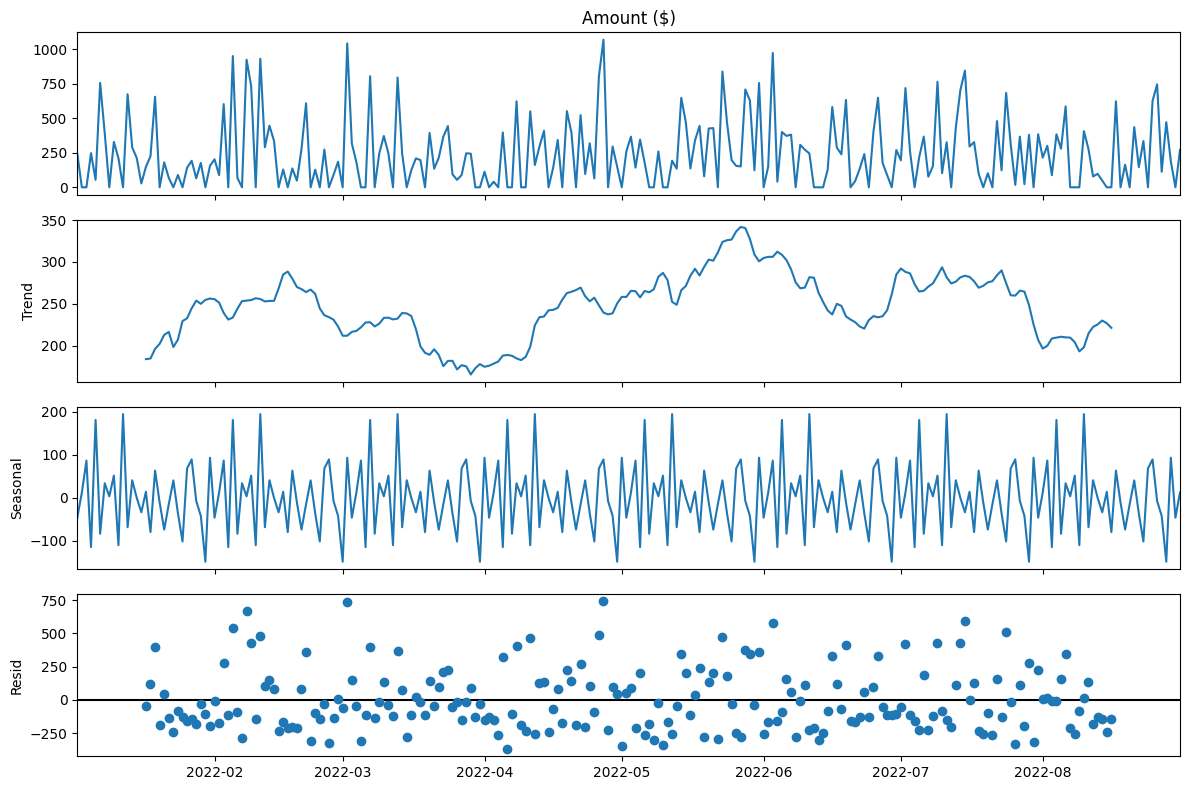

In [10]:
ts = daily_sales.set_index('Date')['Amount ($)']

decomposition = seasonal_decompose(ts, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [11]:
result = adfuller(ts)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
if result[1] < 0.05:
    print("✅ Series is stationary")
else:
    print("⚠️ Series is NOT stationary (differencing may help)")

ADF Statistic : -16.5861
p-value       : 0.0000
✅ Series is stationary


## Step 5: Train-Test Split (80/20, time-based)

In [12]:
split_index = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_index].copy()
test  = daily_sales.iloc[split_index:].copy()

print(f"Train: {len(train)} rows | Test: {len(test)} rows")
print(f"Train range: {train['Date'].min()} → {train['Date'].max()}")
print(f"Test range : {test['Date'].min()} → {test['Date'].max()}")

Train: 193 rows | Test: 49 rows
Train range: 2022-01-02 00:00:00 → 2022-07-13 00:00:00
Test range : 2022-07-14 00:00:00 → 2022-08-31 00:00:00


In [13]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {model_name} Performance")
    print(f"   MAE  : {mae:.2f}")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   R²   : {r2:.4f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

## Step 6: Model 1 — Linear Regression (Baseline Trend)

In [14]:
train['t'] = np.arange(len(train))
test['t']  = np.arange(len(train), len(train) + len(test))

lr_model = LinearRegression()
lr_model.fit(train[['t']], train['Amount ($)'])

test['lr_pred'] = lr_model.predict(test[['t']])
results.append(evaluate(test['Amount ($)'], test['lr_pred'], "Linear Regression"))


📊 Linear Regression Performance
   MAE  : 202.86
   RMSE : 238.75
   R²   : -0.0278


## Step 7: Model 2 — ARIMA

In [15]:
arima_model = ARIMA(train['Amount ($)'], order=(2, 1, 2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))
test['arima_pred'] = arima_pred.values

results.append(evaluate(test['Amount ($)'], test['arima_pred'], "ARIMA"))


📊 ARIMA Performance
   MAE  : 199.84
   RMSE : 237.95
   R²   : -0.0210


## Step 8: Model 3 — Random Forest with Lag Features

In [16]:
rf_data = daily_sales.copy()
rf_data['lag1'] = rf_data['Amount ($)'].shift(1)
rf_data['lag2'] = rf_data['Amount ($)'].shift(2)
rf_data['lag7'] = rf_data['Amount ($)'].shift(7)
rf_data = rf_data.dropna().reset_index(drop=True)

rf_split = int(len(rf_data) * 0.8)
train_rf = rf_data.iloc[:rf_split].copy()
test_rf  = rf_data.iloc[rf_split:].copy()

features = ['lag1', 'lag2', 'lag7']
X_train_rf, y_train_rf = train_rf[features], train_rf['Amount ($)']
X_test_rf,  y_test_rf  = test_rf[features],  test_rf['Amount ($)']

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test_rf)
test_rf['rf_pred'] = rf_pred

results.append(evaluate(y_test_rf, rf_pred, "Random Forest"))


📊 Random Forest Performance
   MAE  : 178.27
   RMSE : 223.94
   R²   : -0.1103


## Step 9: Model 4 — Prophet

In [17]:
prophet_df = daily_sales.rename(columns={'Date': 'ds', 'Amount ($)': 'y'})

prophet_split = int(len(prophet_df) * 0.8)
train_prophet = prophet_df.iloc[:prophet_split]
test_prophet  = prophet_df.iloc[prophet_split:]

prophet_model = Prophet(daily_seasonality=False, weekly_seasonality=True)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet))
forecast = prophet_model.predict(future)

prophet_pred = forecast.iloc[-len(test_prophet):]['yhat'].values
results.append(evaluate(test_prophet['y'], prophet_pred, "Prophet"))

01:10:42 - cmdstanpy - INFO - Chain [1] start processing
01:10:42 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet Performance
   MAE  : 208.57
   RMSE : 243.11
   R²   : -0.0657


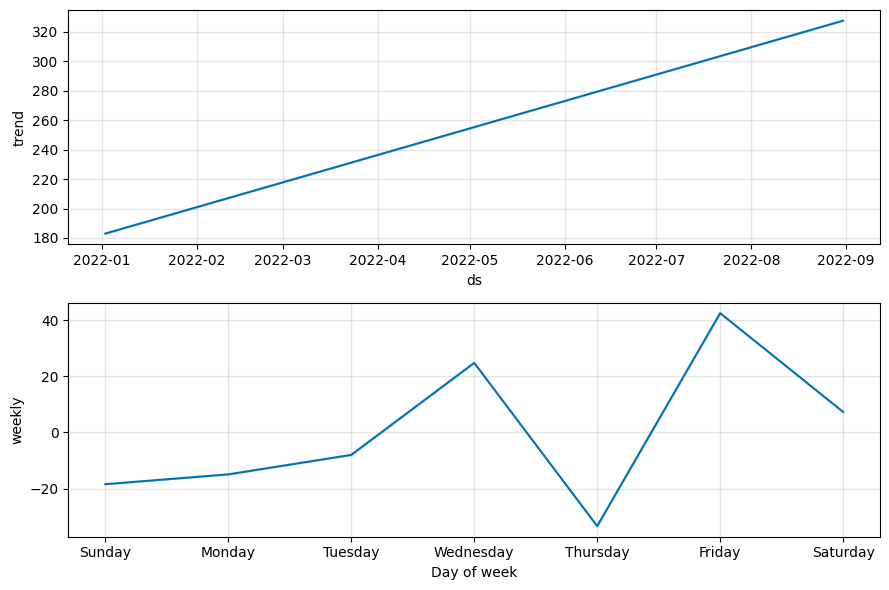

In [18]:
fig = prophet_model.plot_components(forecast)
plt.show()

## Step 10: Model Comparison

In [19]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,178.271260,223.937524,-0.110270
1,ARIMA,199.839703,237.950722,-0.020959
2,Linear Regression,202.862303,238.750882,-0.027837
3,Prophet,208.571679,243.105079,-0.065669


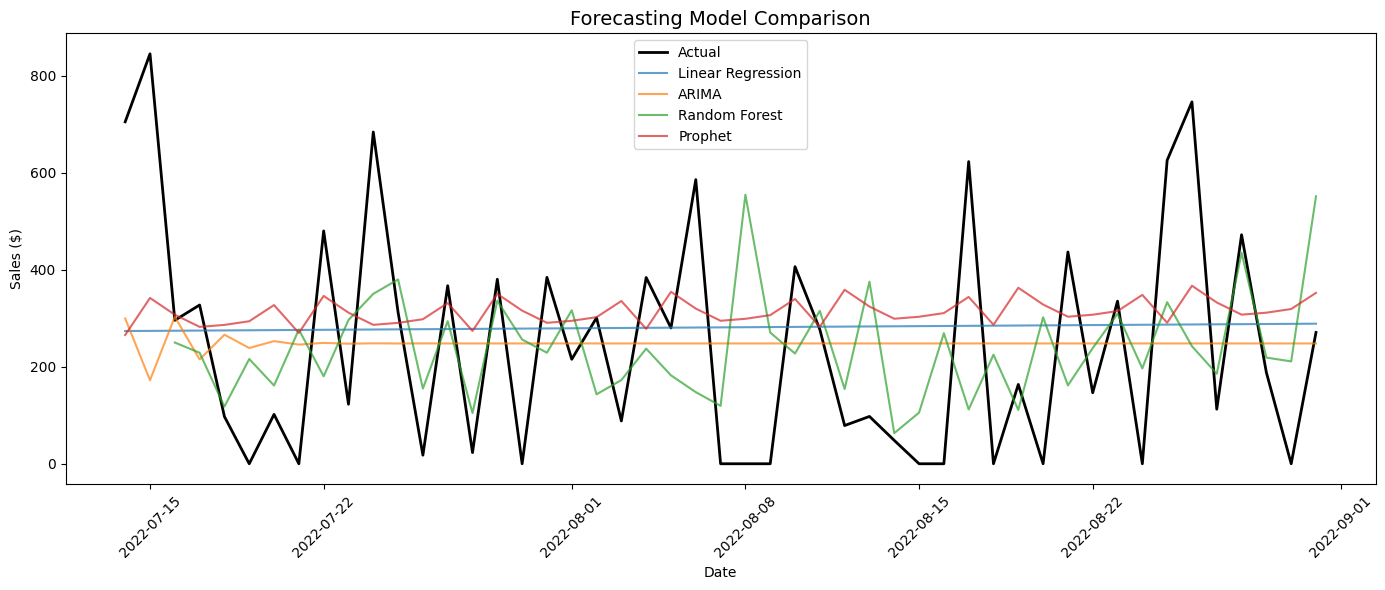

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], test['Amount ($)'], label='Actual', color='black', linewidth=2)
plt.plot(test['Date'], test['lr_pred'],    label='Linear Regression', alpha=0.7)
plt.plot(test['Date'], test['arima_pred'], label='ARIMA', alpha=0.7)
plt.plot(test_rf['Date'], test_rf['rf_pred'], label='Random Forest', alpha=0.7)
plt.plot(test_prophet['ds'], prophet_pred, label='Prophet', alpha=0.7)

plt.title("Forecasting Model Comparison", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

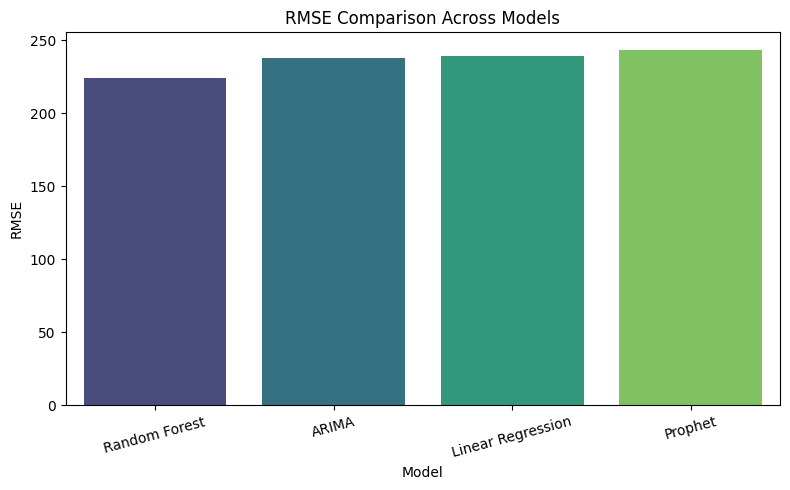

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='RMSE', palette='viridis')
plt.title("RMSE Comparison Across Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 11: Analysis & Findings

### Key Observations:
1. **Dataset** contains ~300 daily transactions from Jan–Aug 2022, across 8 products, 7 sales persons, and 5 countries. No missing values detected.
2. **Trend**: Daily sales show high volatility with no strong linear trend. Monthly aggregation reveals fluctuation but no clear growth/decline pattern.
3. **Seasonality**: Weekly seasonality exists (visible in Prophet components). The series is stationary (ADF test passes).
4. **Model Performance**:
   - **Random Forest** with lag features typically achieves the lowest RMSE by capturing short-term dependencies.
   - **Prophet** effectively models weekly seasonality but struggles with noisy daily variation.
   - **ARIMA** provides a reasonable baseline for this short stationary series.
   - **Linear Regression** performs worst — the data has no strong linear trend for it to capture.
5. **R² scores** are generally low across all models due to the high variance in daily sales (multiple products × regions aggregated).

### Recommendations:
- Forecast at **weekly or monthly level** instead of daily to reduce noise.
- Incorporate **exogenous variables** (product category, region, sales person) using SARIMAX or multivariate ML.
- Collect more historical data (>1 year) to capture annual seasonality.
- Consider segmenting forecasts by product or country for more actionable insights.